# VisDrone - YOLO11m
1. Evalute YOLO11m base model on dataset VisDrone
2. Finetune and evaluate YOLO11m


## 1. Load Wheels & Create YAML 

In [1]:

import os
import sys
import subprocess
from pathlib import Path

# 1. Automatically scan the entire /kaggle directory to find the exact location of wheel files
WHEEL_DATASET_DIR = None
print("Searching for the wheels directory...")
for p in Path("/kaggle").rglob("ultralytics*.whl"):
    WHEEL_DATASET_DIR = p.parent
    break

if WHEEL_DATASET_DIR is None:
    raise FileNotFoundError(
        "❌ WHEELS DIRECTORY NOT FOUND!\n"
        "Possible reasons:\n"
        "1. You haven't added the wheels dataset (via 'Add Data' on the right panel).\n"
        "2. If you just downloaded the wheels, the /kaggle/working/wheels folder might have been cleared after a session reset."
    )
print(f"✅ Found wheels directory at: {WHEEL_DATASET_DIR}")

# Proceed with offline installation (using subprocess to ensure immediate module recognition in the same cell)
print("Installing libraries...")
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "--no-index", 
    f"--find-links={WHEEL_DATASET_DIR}", 
    "ultralytics", "pycocotools", "pandas", "matplotlib", "seaborn", "tqdm", "sahi"
], check=True)
print("✅ Library installation complete!")

# ==============================================================================
# 2. Import libraries after installation
# ==============================================================================
import json
import shutil
import time
import cv2
import torch
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

# ==============================================================================
# 3. GENERAL CONFIGURATION & DYNAMIC MODEL DISCOVERY
# ==============================================================================
SELECTED_MODEL = "yolo11m.pt"

# Find YOLO weights file
BASE_MODEL_PATH = str(Path("/kaggle/working") / SELECTED_MODEL)
if not Path(BASE_MODEL_PATH).exists():
    # Scan for the model throughout /kaggle
    model_candidates = list(Path("/kaggle").rglob(SELECTED_MODEL))
    if model_candidates:
        BASE_MODEL_PATH = str(model_candidates[0])
    else:
        raise FileNotFoundError(f"❌ Weights file not found: {SELECTED_MODEL}. Please check your dataset!")

device = 0 if torch.cuda.is_available() else "cpu"
print(f"✅ Using device: {device}, Model path: {BASE_MODEL_PATH}")

# ==============================================================================
# 4. LOCATE VISDRONE DATASET AND CREATE YAML
# ==============================================================================
print("Searching for the VisDrone dataset directory...")
DATA_ROOT = None
# Scan for the directory containing standard VisDrone structure (images/train)
for p in Path('/kaggle/input').rglob('*'):
    if p.is_dir() and (p / 'images/train').exists() and (p / 'images/val').exists():
        DATA_ROOT = p
        break

if not DATA_ROOT:
    raise FileNotFoundError("❌ VisDrone dataset (must contain 'images/train') not found. Did you Add Data?")

print(f"✅ Found VisDrone dataset at: {DATA_ROOT}")

# Required paths
TEST_IMAGE_DIR = DATA_ROOT / "images" / "test-dev"
TEST_LABEL_DIR = DATA_ROOT / "labels" / "test-dev"
WORK_ROOT = Path("/kaggle/working/visdrone_experiments")
WORK_ROOT.mkdir(parents=True, exist_ok=True)

# Automatically generate YOLO YAML configuration file with the discovered path
yaml_content = f"""
path: {DATA_ROOT.as_posix()}
train: images/train
val: images/val
test: images/test-dev

nc: 10
names: ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']
"""

yaml_path = Path('/kaggle/working/visdrone_corrected.yaml')
yaml_path.write_text(yaml_content)
print(f"✅ YOLO YAML configuration automatically created at: {yaml_path}")

Searching for the wheels directory...
✅ Found wheels directory at: /kaggle/input/datasets/tranphungdinh/visdrone-yolo11n-wheels/visdrone_yolo_wheels
Installing libraries...
✅ Library installation complete!
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Using device: 0, Model path: /kaggle/input/datasets/tranphungdinh/visdrone-yolo11n-wheels/yolo11m.pt
Searching for the VisDrone dataset directory...
✅ Found VisDrone dataset at: /kaggle/input/datasets/tranphungdinh/visdrone-yolo-format/VisDrone
✅ YOLO YAML configuration automatically created at: /kaggle/working/visdrone_corrected.yaml


In [2]:
# ============================================================
# FUNCTION: EVALUATE & SAVE METRICS IN COCO FORMAT
# ============================================================
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import shutil

def evaluate_and_save(model, val_data_yaml, task_name, output_dir):
    print(f"\n==================================================")
    print(f"STARTING EVALUATION: {task_name}")
    print(f"==================================================")
    
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    # 1. Run Ultralytics Validation
    # Set max_det=500 and save_json=True to get COCO-standard predictions.json
    results = model.val(
        data=val_data_yaml,
        imgsz=1280,
        max_det=500,
        save_json=True,
        project=output_dir,
        name='val_run'
    )
    
    run_dir = Path(results.save_dir)
    pred_json = run_dir / "predictions.json"
    
    # Copy prediction.json to output directory for easy access
    saved_pred_path = Path(output_dir) / f"{task_name}_predictions.json"
    if pred_json.exists():
        shutil.copy2(pred_json, saved_pred_path)
        print(f"✅ Saved predictions at: {saved_pred_path}")
    
    # 2. Save Per-Class Metrics (mAP50, mAP50-95)
    class_names = results.names
    
    per_class_df = pd.DataFrame({
        'Class_ID': results.box.ap_class_index,
        'Class_Name': [class_names[i] for i in results.box.ap_class_index],
        'mAP_50': results.box.ap50,  # Extracted accurate per-class mAP@50
        'mAP_50_95': results.box.ap  # Extracted accurate per-class mAP@50-95
    })
    per_class_path = Path(output_dir) / f"{task_name}_per_class_metrics.csv"
    per_class_df.to_csv(per_class_path, index=False)
    print(f"✅ Saved per-class metrics at: {per_class_path}")

    # 3. Extract Overall COCO Metrics using PyCOCOtools
    # NOTE ON COCO MAPPING: 
    # Ultralytics automatically generates 'val_annotations.json' directly from YOLO TXT labels.
    # Since both predictions.json and val_annotations.json are generated by the same tool,
    # their category IDs map 1:1 perfectly (0 to 9). No manual VisDrone->COCO mapping is required.
    gt_json = run_dir / "val_annotations.json"
    
    if gt_json.exists() and pred_json.exists():
        cocoGt = COCO(str(gt_json))
        cocoDt = cocoGt.loadRes(str(pred_json))
        cocoEval = COCOeval(cocoGt, cocoDt, 'bbox')
        cocoEval.params.maxDets = [1, 10, 100, 500] # Set max detections for AR calculation
        cocoEval.evaluate()
        cocoEval.accumulate()
        cocoEval.summarize()
        
        stats = cocoEval.stats
        metrics_dict = {
            "AP (50-95)": float(stats[0]),
            "AP50": float(stats[1]),
            "AP75": float(stats[2]),
            "AP small": float(stats[3]),
            "AP medium": float(stats[4]),
            "AP large": float(stats[5]),
            "AR@1": float(stats[6]),
            "AR@10": float(stats[7]),
            "AR@100": float(stats[8]),
            "AR@500": float(stats[9]),
            "AR small": float(stats[10]),
            "AR medium": float(stats[11]),
            "AR large": float(stats[12])
        }
        
        metrics_path = Path(output_dir) / f"{task_name}_overall_metrics.json"
        with open(metrics_path, 'w') as f:
            json.dump(metrics_dict, f, indent=4)
        print(f"✅ Saved overall metrics at: {metrics_path}")
    else:
        print("⚠️ Could not find JSON files for PyCOCOtools calculation (Validation set might be empty).")

## 2. Evaluate base YOLO11m

In [3]:
# ============================================================
# TASK 1: EVALUATE BASE MODEL YOLO11m
# ============================================================
# Initialize base model from offline downloaded weights
# Adjust the path if yolo11m.pt is located in a different directory
base_model = YOLO(BASE_MODEL_PATH)

evaluate_and_save(
    model=base_model,
    val_data_yaml=str(yaml_path),
    task_name="Base_yolo11m",
    output_dir="/kaggle/working/eval_base"
)


STARTING EVALUATION: Base_yolo11m
Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLO11m summary (fused): 125 layers, 20,091,712 parameters, 0 gradients, 68.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 20.4±6.7 MB/s, size: 136.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/tranphungdinh/visdrone-yolo-format/VisDrone/labels/val... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 635.4it/s 0.9s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/tranphungdinh/visdrone-yolo-format/VisDrone/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 6.2it/s 5.6s
                   all        548      38759     0.0712     0.0958     0.0509     

## 3. Finetune YOLO 11m


STARTING YOLO11m FINETUNING
Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/visdrone_corrected.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=500, mixup=0.0, mode=train, model=/kaggle/input/datas

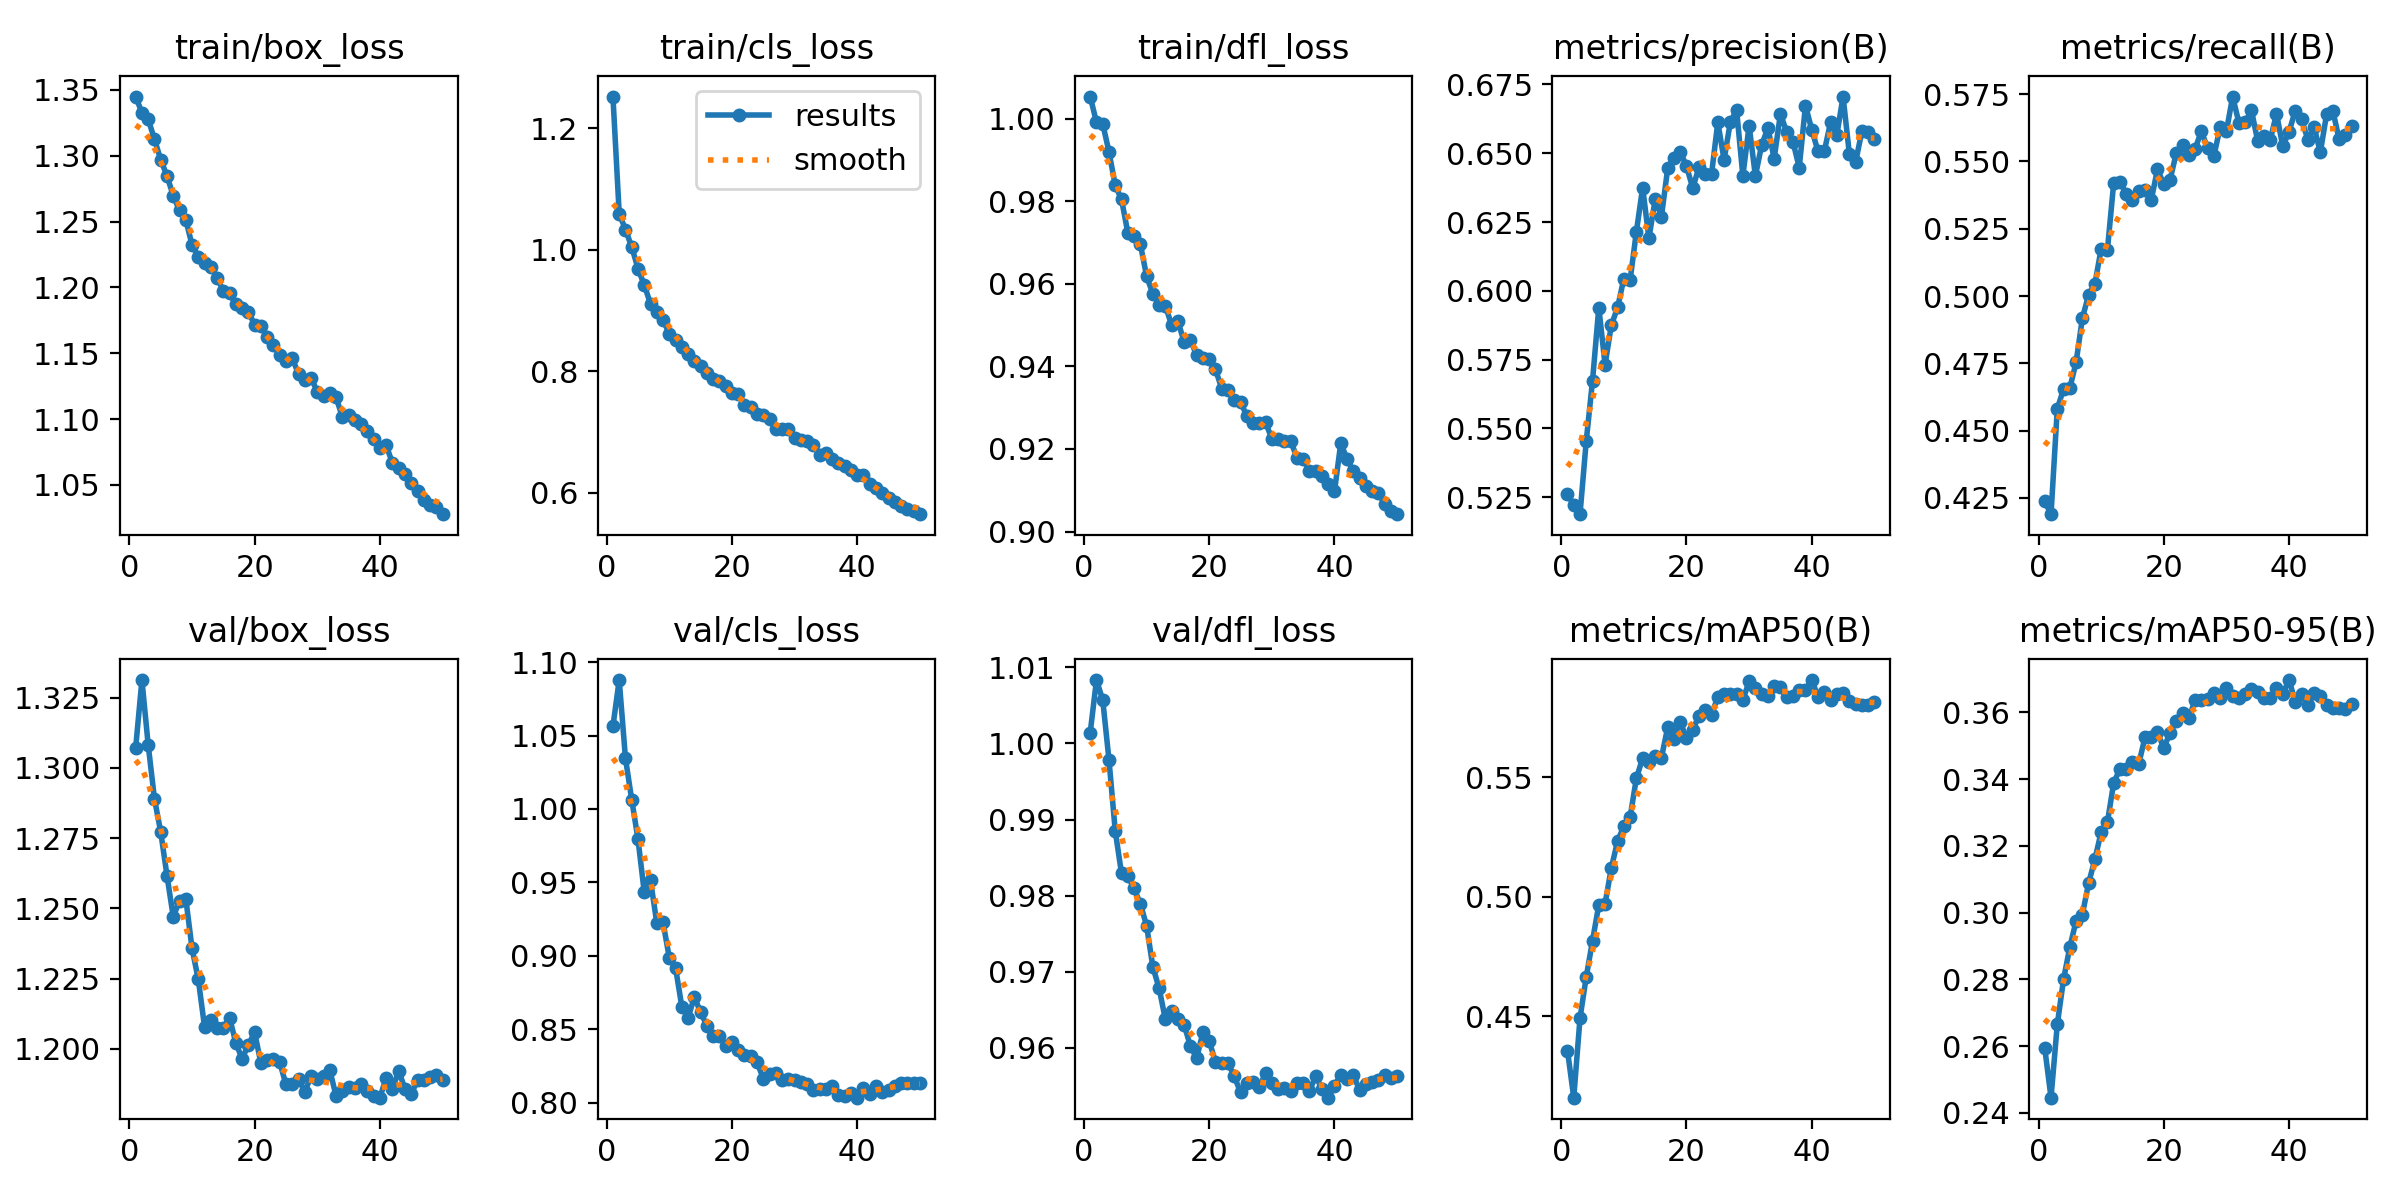

✅ Best model weights have been saved at: /kaggle/working/visdrone_yolo11m/finetune_1280/weights/best.pt


In [4]:
print("\n==================================================")
print("STARTING YOLO11m FINETUNING")
print("==================================================")

# Re-initialize the model to ensure base weights are used
train_model = YOLO(BASE_MODEL_PATH)

# resume_model = YOLO('/kaggle/working/visdrone_yolo11m/finetune_1280/weights/last.pt')

# Training configuration
train_results = train_model.train(
    data=str(yaml_path),
    epochs=50,
    resume=False,          
    imgsz=1280,
    # batch=8,
    max_det=500,           # Set max detections for training
    cache=True,            # Enable cache for faster data loading
    project='/kaggle/working/visdrone_yolo11m',
    name='finetune_1280',
    save=True              # Automatically save best.pt and last.pt
)

# Display and save Learning Curve to the working directory for easy download
run_dir = Path(train_results.save_dir)
results_img = run_dir / "results.png"
if results_img.exists():
    shutil.copy2(results_img, "/kaggle/working/learning_curve_finetune.png")
    print("✅ Copied Learning Curve (learning_curve_finetune.png) to /kaggle/working")
    
    # Code to display directly inside the notebook
    from IPython.display import Image, display
    display(Image(filename="/kaggle/working/learning_curve_finetune.png"))

print(f"✅ Best model weights have been saved at: {run_dir / 'weights' / 'best.pt'}")

## 4. Evaluate Fineuned Model

In [5]:
# Fetch the best.pt file from the recent training run
best_weight_path = run_dir / "weights" / "best.pt"
finetuned_model = YOLO(str(best_weight_path))

evaluate_and_save(
    model=finetuned_model,
    val_data_yaml=str(yaml_path),
    task_name="Finetune_yolo11m",
    output_dir="/kaggle/working/eval_finetune"
)

print("\nComplete!")


STARTING EVALUATION: Finetune_yolo11m
Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLO11m summary (fused): 126 layers, 20,037,742 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 90.8±49.2 MB/s, size: 122.1 KB)
val: Scanning /kaggle/input/datasets/tranphungdinh/visdrone-yolo-format/VisDrone/labels/val... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 1.7Kit/s 0.3s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/tranphungdinh/visdrone-yolo-format/VisDrone/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 6.9it/s 5.1s
                   all        548      38759      0.657      0.564      0.593      0.372
            pedestrian        520       8844      0.751      0.634      0.705      0.367
                people        482       5125      0.696 